In [1]:
from keras.models import load_model
model = load_model('MFCC_model.keras')

Found 45234 audio files with corresponding labels.
Training set distribution: [18093 18094]
Validation set distribution: [4524 4523]


d:\download\fyp\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 352s 307ms/step - accuracy: 0.7574 - loss: 0.5106 - val_accuracy: 0.8219 - val_loss: 0.3982
Epoch 2/5
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 324s 286ms/step - accuracy: 0.8332 - loss: 0.3569 - val_accuracy: 0.8871 - val_loss: 0.2632
Epoch 3/5
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 311s 275ms/step - accuracy: 0.8922 - loss: 0.2395 - val_accuracy: 0.9282 - val_loss: 0.1773
Epoch 4/5
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 297s 263ms/step - accuracy: 0.9245 - loss: 0.1715 - val_accuracy: 0.9546 - val_loss: 0.1201
Epoch 5/5
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 295s 260ms/step - accuracy: 0.9438 - loss: 0.1284 - val_accuracy: 0.9643 - val_loss: 0.1017


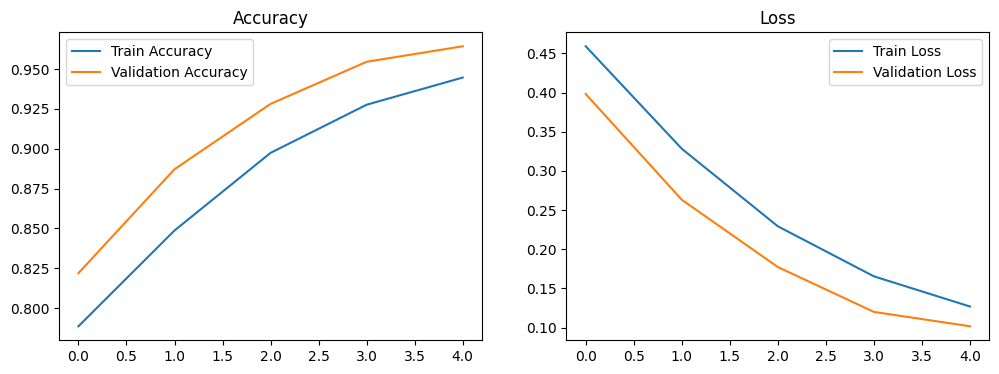

In [31]:
import glob
import os
import librosa
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
import tensorflow as tf
from tensorflow.keras import layers, models

# Path to the metadata file
metadata_file_path = r'D:\download\Compressed\DF-keys-full\keys\DF\CM\trial_metadata.txt'

# Dictionary to hold file identifiers and labels
labels = {}

# Open and read the metadata file
with open(metadata_file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        file_identifier = parts[1]  # Example: DF_E_2000011
        label = parts[5]            # Example: "spoof"
        labels[file_identifier] = label

# Directory containing the undersampled audio files
undersampled_audio_dir = r'D:\audio_files\undersampled_audio'

# Find all .flac files in the undersampled directory
audio_files = glob.glob(os.path.join(undersampled_audio_dir, '*.flac'))

# Create a list to store only those files that have corresponding labels in the metadata
valid_audio_files = []
valid_labels = []

# Loop through the audio files and match with metadata labels
for audio_file in audio_files:
    file_name = os.path.basename(audio_file)
    file_identifier = file_name.split('.')[0]  # Extract the file identifier (before the extension)

    # Check if the file identifier exists in the metadata labels
    if file_identifier in labels:
        valid_audio_files.append(audio_file)  # Keep this audio file
        valid_labels.append(labels[file_identifier])  # Store the corresponding label (spoof/bonafide)

# Print the number of matching files
print(f"Found {len(valid_audio_files)} audio files with corresponding labels.")

# Audio to MFCC conversion function
def audio_to_mfcc(audio_file, sr=22050, n_mfcc=13):
    """Convert audio to MFCC."""
    audio, sample_rate = librosa.load(audio_file, sr=sr)
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    return mfcc

# Resize the MFCC to a fixed size function
def resize_spectrogram(spectrogram, target_size=(128, 128)):
    """Resize the MFCC to a fixed size."""
    return cv2.resize(spectrogram, target_size)

# Preprocessing the audio files
def preprocess_audio_files(audio_files, labels, target_size=(128, 128)):
    """Convert audio files to MFCCs, resize, and normalize them."""
    mfcc_data = []
    label_data = []

    for audio_file, label in zip(audio_files, labels):
        mfcc = audio_to_mfcc(audio_file)
        resized_mfcc = resize_spectrogram(mfcc, target_size)
        
        # Safe normalization: Check if the max value is 0
        max_value = np.max(resized_mfcc)
        if max_value > 0:
            normalized_mfcc = resized_mfcc / max_value
        else:
            normalized_mfcc = resized_mfcc  # Leave it as is if the max is 0

        mfcc_data.append(normalized_mfcc)
        label_data.append(1 if label == 'spoof' else 0)  # Binary label (1: spoof, 0: bonafide)

    return np.array(mfcc_data), np.array(label_data)

# Preprocess the valid audio files and labels
X, y = preprocess_audio_files(valid_audio_files, valid_labels, target_size=(128, 128))

# Add a channel dimension for CNN
X = np.expand_dims(X, axis=-1)

# Stratified splitting to preserve label distribution
def stratified_split(X, y, test_size=0.2, random_state=42):
    """Split dataset into stratified training and validation sets."""
    strat_split = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    
    for train_idx, val_idx in strat_split.split(X, y):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
    return X_train, X_val, y_train, y_val

# Perform the stratified split
X_train, X_val, y_train, y_val = stratified_split(X, y, test_size=0.2, random_state=42)

# Print the distribution of classes in training and validation sets to verify stratification
print(f"Training set distribution: {np.bincount(y_train)}")
print(f"Validation set distribution: {np.bincount(y_val)}")

# CNN Model Definition
def build_cnn(input_shape):
    model = models.Sequential()
    
    # 1st Convolutional Layer
    model.add(layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # 2nd Convolutional Layer
    model.add(layers.Conv2D(64, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # 3rd Convolutional Layer
    model.add(layers.Conv2D(128, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Flatten the output and add fully connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))

    # Output layer (binary classification)
    model.add(layers.Dense(1, activation='sigmoid'))

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# Define the input shape for the CNN
input_shape = (128, 128, 1)

# Build the model
model = build_cnn(input_shape)

# Print the model summary
model.summary()

# Define early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_val, y_val), callbacks=[early_stopping])

# Plot accuracy and loss curves
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()


In [19]:

#Load unseen data
unseen_audio_file = r"C:\Users\Hariz\Downloads\fakeyou_6m3yreh4w07azyne826h0kdkmbn7tfre.wav"  #TTS Fakeyou
preprocessed_audio = preprocess_audio(unseen_audio_file)

# Make prediction
prediction = model.predict(preprocessed_audio)

# Assuming binary classification, apply a threshold to get class label
predicted_probability = prediction[0][0]  # Get the probability of the positive class (spoof)
predicted_class = 1 if predicted_probability > 0.5 else 0  # Adjust threshold as needed

# Convert to percentage
predicted_percentage = predicted_probability * 100  # Convert to percentage

# Print the result
print(f"Predicted Class: {predicted_class} (1: spoof, 0: bonafide)")
print(f"Confidence: {predicted_percentage:.2f}%")  # Display the confidence in percentage format

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted Class: 1 (1: spoof, 0: bonafide)
Confidence: 100.00%


In [20]:
#Load unseen data
unseen_audio_file = r"C:\Users\Hariz\Downloads\fakeyou_6m3yreh4w07azyne826h0kdkmbn7tfre.wav"  #
preprocessed_audio = preprocess_audio(unseen_audio_file)

# Make prediction
prediction = model.predict(preprocessed_audio)

# Assuming binary classification, apply a threshold to get class label
predicted_probability = prediction[0][0]  # Get the probability of the positive class (spoof)
predicted_class = 1 if predicted_probability > 0.5 else 0  # Adjust threshold as needed

# Convert to percentage
predicted_percentage = predicted_probability * 100  # Convert to percentage

# Print the result
print(f"Predicted Class: {predicted_class} (1: spoof, 0: bonafide)")
print(f"Confidence: {predicted_percentage:.2f}%")  # Display the confidence in percentage format

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted Class: 1 (1: spoof, 0: bonafide)
Confidence: 100.00%


Found 45234 audio files with corresponding labels.
Training set distribution: [1583 1583]
Validation set distribution: [339 340]
Test set distribution: [340 339]


d:\download\fyp\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
99/99 ━━━━━━━━━━━━━━━━━━━━ 33s 309ms/step - accuracy: 0.7100 - loss: 0.5885 - val_accuracy: 0.7717 - val_loss: 0.4958
Epoch 2/5
99/99 ━━━━━━━━━━━━━━━━━━━━ 30s 306ms/step - accuracy: 0.7715 - loss: 0.4990 - val_accuracy: 0.7879 - val_loss: 0.4539
Epoch 3/5
99/99 ━━━━━━━━━━━━━━━━━━━━ 32s 321ms/step - accuracy: 0.7936 - loss: 0.4387 - val_accuracy: 0.8027 - val_loss: 0.4304
Epoch 4/5
99/99 ━━━━━━━━━━━━━━━━━━━━ 25s 249ms/step - accuracy: 0.8100 - loss: 0.4451 - val_accuracy: 0.8071 - val_loss: 0.4064
Epoch 5/5
99/99 ━━━━━━━━━━━━━━━━━━━━ 26s 267ms/step - accuracy: 0.8280 - loss: 0.3753 - val_accuracy: 0.8130 - val_loss: 0.4120


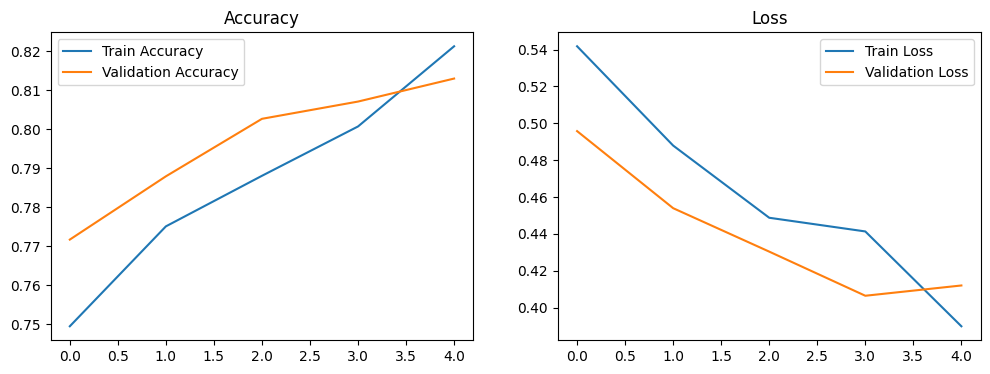

In [2]:
import glob
import os
import librosa
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
import tensorflow as tf
from tensorflow.keras import layers, models

# Path to the metadata file
metadata_file_path = r'D:\download\Compressed\DF-keys-full\keys\DF\CM\trial_metadata.txt'

# Dictionary to hold file identifiers and labels
labels = {}

# Open and read the metadata file
with open(metadata_file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        file_identifier = parts[1]  # Example: DF_E_2000011
        label = parts[5]            # Example: "spoof"
        labels[file_identifier] = label

# Directory containing the undersampled audio files
undersampled_audio_dir = r'D:\audio_files\undersampled_audio'

# Find all .flac files in the undersampled directory
audio_files = glob.glob(os.path.join(undersampled_audio_dir, '*.flac'))

# Create a list to store only those files that have corresponding labels in the metadata
valid_audio_files = []
valid_labels = []

# Loop through the audio files and match with metadata labels
for audio_file in audio_files:
    file_name = os.path.basename(audio_file)
    file_identifier = file_name.split('.')[0]  # Extract the file identifier (before the extension)

    # Check if the file identifier exists in the metadata labels
    if file_identifier in labels:
        valid_audio_files.append(audio_file)  # Keep this audio file
        valid_labels.append(labels[file_identifier])  # Store the corresponding label (spoof/bonafide)

# Print the number of matching files
print(f"Found {len(valid_audio_files)} audio files with corresponding labels.")

# Audio to MFCC conversion function
def audio_to_mfcc(audio_file, sr=22050, n_mfcc=13):
    """Convert audio to MFCC."""
    audio, sample_rate = librosa.load(audio_file, sr=sr)
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    return mfcc

# Resize the MFCC to a fixed size function
def resize_spectrogram(spectrogram, target_size=(128, 128)):
    """Resize the MFCC to a fixed size."""
    return cv2.resize(spectrogram, target_size)

# Preprocessing the audio files
def preprocess_audio_files(audio_files, labels, target_size=(128, 128)):
    """Convert audio files to MFCCs, resize, and normalize them."""
    mfcc_data = []
    label_data = []

    for audio_file, label in zip(audio_files, labels):
        mfcc = audio_to_mfcc(audio_file)
        resized_mfcc = resize_spectrogram(mfcc, target_size)
        
        # Safe normalization: Check if the max value is 0
        max_value = np.max(resized_mfcc)
        if max_value > 0:
            normalized_mfcc = resized_mfcc / max_value
        else:
            normalized_mfcc = resized_mfcc  # Leave it as is if the max is 0

        mfcc_data.append(normalized_mfcc)
        label_data.append(1 if label == 'spoof' else 0)  # Binary label (1: spoof, 0: bonafide)

    return np.array(mfcc_data), np.array(label_data)

# Preprocess the valid audio files and labels
X, y = preprocess_audio_files(valid_audio_files, valid_labels, target_size=(128, 128))

# Add a channel dimension for CNN
X = np.expand_dims(X, axis=-1)

# Sample 10% of the data with balanced classes
def sample_data(X, y, sample_size=0.1, random_state=42):
    """Sample 10% of the dataset, ensuring equal classes."""
    strat_split = StratifiedShuffleSplit(n_splits=1, test_size=sample_size, random_state=random_state)
    
    for _, sample_idx in strat_split.split(X, y):
        X_sample, y_sample = X[sample_idx], y[sample_idx]
    
    # Ensure classes are balanced within the sampled data
    class_counts = np.bincount(y_sample)
    min_class_count = min(class_counts)
    spoof_indices = np.where(y_sample == 1)[0][:min_class_count]
    bonafide_indices = np.where(y_sample == 0)[0][:min_class_count]
    
    balanced_indices = np.concatenate([spoof_indices, bonafide_indices])
    X_balanced, y_balanced = X_sample[balanced_indices], y_sample[balanced_indices]
    
    return X_balanced, y_balanced

# Sample and balance the data
X_sampled, y_sampled = sample_data(X, y, sample_size=0.1, random_state=42)

# Stratified 70/15/15 split to preserve label distribution
def stratified_split_70_15_15(X, y, test_size=0.15, val_size=0.15, random_state=42):
    """Split dataset into stratified 70/15/15 sets."""
    strat_split1 = StratifiedShuffleSplit(n_splits=1, test_size=(test_size + val_size), random_state=random_state)
    
    for train_idx, test_val_idx in strat_split1.split(X, y):
        X_train, y_train = X[train_idx], y[train_idx]
        X_test_val, y_test_val = X[test_val_idx], y[test_val_idx]
    
    # Now split the remaining 30% into 15% validation and 15% test
    strat_split2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=random_state)
    for val_idx, test_idx in strat_split2.split(X_test_val, y_test_val):
        X_val, y_val = X_test_val[val_idx], y_test_val[val_idx]
        X_test, y_test = X_test_val[test_idx], y_test_val[test_idx]
    
    # Ensure that the training set has balanced classes
    class_counts = np.bincount(y_train)
    min_class_count = min(class_counts)
    spoof_indices = np.where(y_train == 1)[0][:min_class_count]
    bonafide_indices = np.where(y_train == 0)[0][:min_class_count]
    balanced_train_indices = np.concatenate([spoof_indices, bonafide_indices])
    X_train_balanced, y_train_balanced = X_train[balanced_train_indices], y_train[balanced_train_indices]

    return X_train_balanced, X_val, X_test, y_train_balanced, y_val, y_test

# Perform the stratified 70/15/15 split
X_train, X_val, X_test, y_train, y_val, y_test = stratified_split_70_15_15(X_sampled, y_sampled, test_size=0.15, val_size=0.15, random_state=42)

# Print the distribution of classes to verify stratification
print(f"Training set distribution: {np.bincount(y_train)}")
print(f"Validation set distribution: {np.bincount(y_val)}")
print(f"Test set distribution: {np.bincount(y_test)}")

# CNN Model Definition
def build_cnn(input_shape):
    model = models.Sequential()
    
    # 1st Convolutional Layer
    model.add(layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # 2nd Convolutional Layer
    model.add(layers.Conv2D(64, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # 3rd Convolutional Layer
    model.add(layers.Conv2D(128, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Flatten the output and add fully connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))

    # Output layer (binary classification)
    model.add(layers.Dense(1, activation='sigmoid'))

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# Define the input shape for the CNN
input_shape = (128, 128, 1)

# Build the model
model = build_cnn(input_shape)

# Print the model summary
model.summary()

# Define early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_val, y_val), callbacks=[early_stopping])

# Plot accuracy and loss curves
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()
